In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
path = "datos/BBDD Ventas 25 - 26.xlsx"
df = pd.read_excel(path, header=1)

In [9]:
columnas = df.columns
columnas = [col for col in columnas if 'Unnamed' not in str(col)]

print(len(columnas))
print(columnas)

43
[1, 'MARCA', 'CANAL HANA', 'ZONAL HANA', 'CONSOLIDADO', 'COD. CLIENTE PADRE', 'NOM. CLIENTE PADRE', 'FAMILIA HANA', 'SKU', 'Descripción', 'KILOS', 'VENTAS', 'APORTE', 'COSTO', 'Familia', 'Clasificacíón', 'Ref./Cong.', 'Minifábrica', 'Denom. Mantencion', 'SUBFAMILIA', 'Planta/Maquila', 'AGR.1', 'ZONAL', 'ZONA', 'CANAL CG', 'SUB FAMILIA (NIELSEN)', 'TIPO CARNE', 'Aporte Mes Hana $', 'Mes', 'Año', 'Mes.1', 'Tons', 'Ingreso $M', 'Aporte $M', 'Costo M$', 'Ingreso Neto $', 'Margen1 $', 'Margen2 $', 'Ebitda  ABC $', 'Gastos Directos $M', 'Gastos F. Indirectos $M', 'Denom', 'Cadena']


In [43]:
columnas_importantes = [
    'Mes', # Tiempo  
    'SKU', 'Descripción', 'MARCA', 'FAMILIA HANA', 'TIPO CARNE', # Producto
    'CANAL HANA', 'ZONAL HANA', # Cliente
    'KILOS', # Q
    'VENTAS' # P
]
df_modelo = df[columnas_importantes].copy()

In [44]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 434066 entries, 0 to 434065
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Mes           434066 non-null  object 
 1   SKU           434066 non-null  int64  
 2   Descripción   434066 non-null  str    
 3   MARCA         434066 non-null  str    
 4   FAMILIA HANA  434066 non-null  str    
 5   TIPO CARNE    433952 non-null  str    
 6   CANAL HANA    434066 non-null  str    
 7   ZONAL HANA    434066 non-null  str    
 8   KILOS         434066 non-null  float64
 9   VENTAS        434066 non-null  int64  
dtypes: float64(1), int64(2), object(1), str(6)
memory usage: 33.1+ MB


In [45]:
df_modelo.head()

,Mes,SKU,Descripción,MARCA,FAMILIA HANA,TIPO CARNE,CANAL HANA,ZONAL HANA,KILOS,VENTAS
0,2025-01-01 00:00:00,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,ANTOFAGASTA,2170.672,10641375
1,2025-01-01 00:00:00,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,ANTOFAGASTA,516.966,2455064
2,2025-01-01 00:00:00,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,ARICA,469.718,2276539
3,2025-01-01 00:00:00,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,ARICA,34.554,164684
4,2025-01-01 00:00:00,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,ARICA,168.120,801263


In [46]:
# Normalizar Mes: mezcla de datetime + serial de fecha Excel (int)
mes_num = pd.to_numeric(df_modelo['Mes'], errors='coerce')
mask_excel = mes_num.notna()
mes_dt = pd.to_datetime(df_modelo['Mes'].where(~mask_excel), errors='coerce')
mes_dt.loc[mask_excel] = pd.to_datetime(mes_num.loc[mask_excel], unit='D', origin='1899-12-30')
df_modelo['Mes'] = mes_dt

# Calcular ventas por mes para cada familia en cada canal, zona
ventas_mensuales = (
    df_modelo.groupby(['Mes', 'FAMILIA HANA', 'CANAL HANA', 'ZONAL HANA'], as_index=False)['VENTAS']
    .sum()
)

In [47]:
ventas_mensuales.head()

,Mes,FAMILIA HANA,CANAL HANA,ZONAL HANA,VENTAS
0,2025-01-01,ARROLLADOS,HR,ANTOFAGASTA,1544591
1,2025-01-01,ARROLLADOS,HR,ARICA,14272
2,2025-01-01,ARROLLADOS,HR,CALAMA,447799
3,2025-01-01,ARROLLADOS,HR,CHILLAN,144995
4,2025-01-01,ARROLLADOS,HR,CONCEPCION,1272693


In [48]:
# Calcular precio unitario promedio por mes, familia, canal, zona
precio_unitario = (
    df_modelo.groupby(['Mes', 'FAMILIA HANA', 'CANAL HANA', 'ZONAL HANA'], as_index=False)
    .apply(lambda x: np.sum(x['VENTAS']) / np.sum(x['KILOS']) if np.sum(x['KILOS']) > 0 else 0)
).rename(columns={"NaN": 'precio_unitario'})

In [49]:
precio_unitario.columns = ['Mes', 'FAMILIA HANA', 'CANAL HANA', 'ZONAL HANA', 'Precio Unitario Promedio']
precio_unitario.head()

,Mes,FAMILIA HANA,CANAL HANA,ZONAL HANA,Precio Unitario Promedio
0,2025-01-01,ARROLLADOS,HR,ANTOFAGASTA,4978.552711
1,2025-01-01,ARROLLADOS,HR,ARICA,4912.908778
2,2025-01-01,ARROLLADOS,HR,CALAMA,4924.331398
3,2025-01-01,ARROLLADOS,HR,CHILLAN,5474.401571
4,2025-01-01,ARROLLADOS,HR,CONCEPCION,4114.154100


In [50]:
# Unir en un df final
df_final = pd.merge(ventas_mensuales, precio_unitario, on=['Mes', 'FAMILIA HANA', 'CANAL HANA', 'ZONAL HANA'])

In [51]:
df_final.head()

,Mes,FAMILIA HANA,CANAL HANA,ZONAL HANA,VENTAS,Precio Unitario Promedio
0,2025-01-01,ARROLLADOS,HR,ANTOFAGASTA,1544591,4978.552711
1,2025-01-01,ARROLLADOS,HR,ARICA,14272,4912.908778
2,2025-01-01,ARROLLADOS,HR,CALAMA,447799,4924.331398
3,2025-01-01,ARROLLADOS,HR,CHILLAN,144995,5474.401571
4,2025-01-01,ARROLLADOS,HR,CONCEPCION,1272693,4114.154100


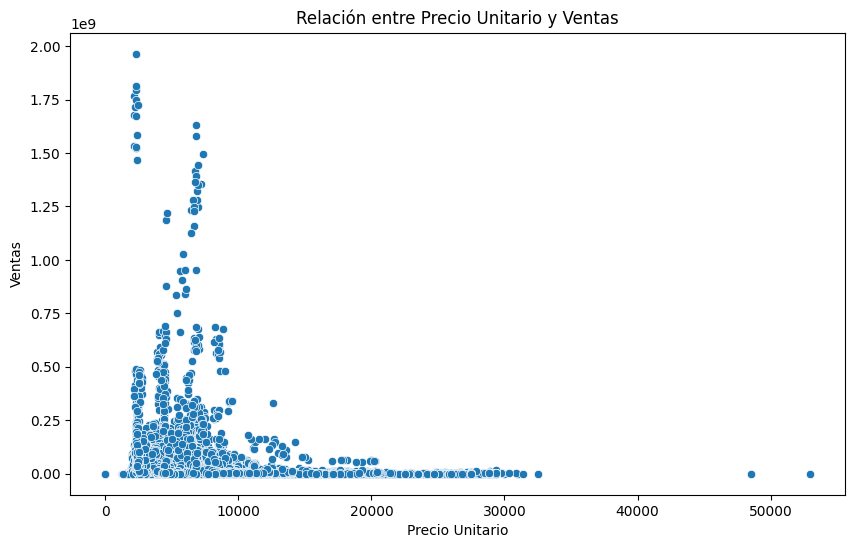

In [53]:
# Armar gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Precio Unitario Promedio', y='VENTAS')
plt.title('Relación entre Precio Unitario y Ventas')
plt.xlabel('Precio Unitario')
plt.ylabel('Ventas')
plt.show()

In [55]:
# Limpiar outliers
df_final = df_final[df_final['Precio Unitario Promedio'].between(df_final['Precio Unitario Promedio'].quantile(0.25), df_final['Precio Unitario Promedio'].quantile(0.75))]

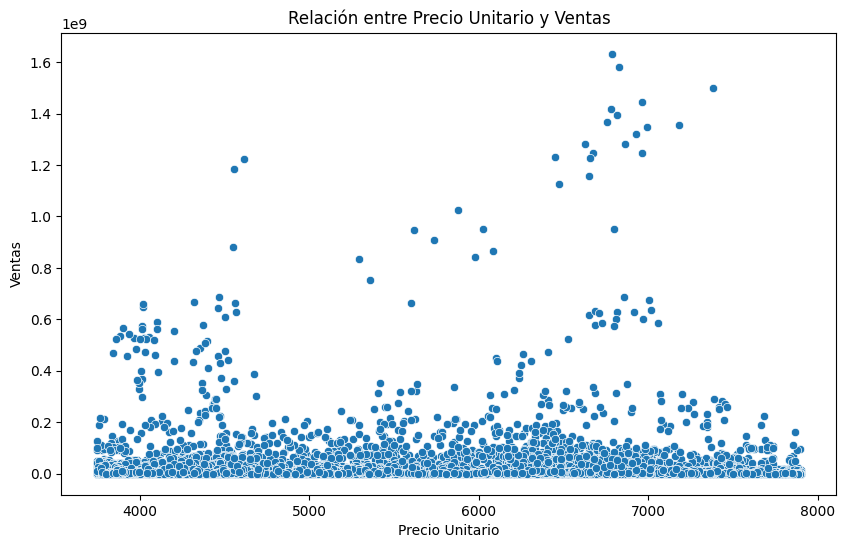

In [56]:
# Armar gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='Precio Unitario Promedio', y='VENTAS')
plt.title('Relación entre Precio Unitario y Ventas')
plt.xlabel('Precio Unitario')
plt.ylabel('Ventas')
plt.show()

In [58]:
import statsmodels.api as sm

# =========================
# 4. Base para regresión (adaptada a tus columnas reales)
# =========================
base_regresion = df_final.rename(columns={
    'FAMILIA HANA': 'familia',
    'CANAL HANA': 'canal',
    'ZONAL HANA': 'zona',
    'VENTAS': 'ventas',
    'Precio Unitario Promedio': 'precio'
}).copy()

# =========================
# 5. Función de regresión log-log por grupo
# =========================
def calcular_elasticidad_loglog(grupo, min_obs=6):
    """
    Estima:
        log(ventas) = a + b * log(precio)
    y retorna b como elasticidad.
    """

    data = grupo.copy()

    # Mantener solo observaciones válidas para log()
    data['ventas'] = pd.to_numeric(data['ventas'], errors='coerce')
    data['precio'] = pd.to_numeric(data['precio'], errors='coerce')
    data = data[(data['ventas'] > 0) & (data['precio'] > 0)].copy()

    n = len(data)
    if n < min_obs:
        return pd.Series({
            'n_obs': n,
            'elasticidad': np.nan,
            'intercepto': np.nan,
            'p_value': np.nan,
            'r2': np.nan,
            'precio_min': data['precio'].min() if n > 0 else np.nan,
            'precio_max': data['precio'].max() if n > 0 else np.nan,
            'comentario': f'Menos de {min_obs} observaciones válidas'
        })

    if data['precio'].nunique() < 2:
        return pd.Series({
            'n_obs': n,
            'elasticidad': np.nan,
            'intercepto': np.nan,
            'p_value': np.nan,
            'r2': np.nan,
            'precio_min': data['precio'].min(),
            'precio_max': data['precio'].max(),
            'comentario': 'Precio sin variación suficiente'
        })

    data['log_ventas'] = np.log(data['ventas'])
    data['log_precio'] = np.log(data['precio'])

    X = sm.add_constant(data['log_precio'])
    y = data['log_ventas']

    try:
        modelo = sm.OLS(y, X).fit(cov_type='HC1')

        return pd.Series({
            'n_obs': n,
            'elasticidad': modelo.params['log_precio'],
            'intercepto': modelo.params['const'],
            'p_value': modelo.pvalues['log_precio'],
            'r2': modelo.rsquared,
            'precio_min': data['precio'].min(),
            'precio_max': data['precio'].max(),
            'comentario': 'OK'
        })

    except Exception as e:
        return pd.Series({
            'n_obs': n,
            'elasticidad': np.nan,
            'intercepto': np.nan,
            'p_value': np.nan,
            'r2': np.nan,
            'precio_min': data['precio'].min() if n > 0 else np.nan,
            'precio_max': data['precio'].max() if n > 0 else np.nan,
            'comentario': f'Error: {str(e)}'
        })

# =========================
# 6. Aplicar regresión por familia-canal-zona
# =========================
group_cols = ['familia', 'canal', 'zona']

resultados = (
    base_regresion.groupby(group_cols, dropna=False)
      .apply(calcular_elasticidad_loglog, min_obs=6)
      .reset_index()
)

# =========================
# 7. Ordenar resultados
# =========================
resultados = resultados.sort_values(group_cols).reset_index(drop=True)
resultados.head()


,familia,canal,zona,n_obs,elasticidad,intercepto,p_value,r2,precio_min,precio_max,comentario
0,ARROLLADOS,HR,ANTOFAGASTA,14,-11.536737,112.384628,0.001825,0.521498,4685.709415,5001.644212,OK
1,ARROLLADOS,HR,ARICA,2,NaN,NaN,NaN,NaN,4912.908778,5602.222222,Menos de 6 observaciones válidas
2,ARROLLADOS,HR,CALAMA,14,-13.905944,131.266313,0.011513,0.394444,4918.829482,5064.696996,OK
3,ARROLLADOS,HR,CHILLAN,14,1.014205,1.946021,0.554534,0.022346,4912.868949,6383.521657,OK
4,ARROLLADOS,HR,CONCEPCION,14,-0.207895,15.647177,0.964386,0.000120,4114.154100,4269.338257,OK


In [61]:
criterio_r2 = resultados['r2'] > 0.5
criterio_p = resultados['p_value'] < 0.05
ambos_criterios = criterio_r2 & criterio_p

print("Número de grupos con r2 > 0.5:", criterio_r2.sum())

print("Número de grupos con elasticidad significativa (p < 0.05):", criterio_p.sum())

print("Número de grupos con ambos criterios:", ambos_criterios.sum())

Número de grupos con r2 > 0.5: 81
Número de grupos con elasticidad significativa (p < 0.05): 278
Número de grupos con ambos criterios: 81


In [63]:
resultados.sort_values('elasticidad', ascending=True).head(10)

,familia,canal,zona,n_obs,elasticidad,intercepto,p_value,r2,precio_min,precio_max,comentario
195,EMPANIZADOS,HR,SANTIAGO,7,-380787.250755,3.146486e+06,9.302840e-07,0.445136,3877.989418,3878.000000,OK
182,EMPANIZADOS,HR,CHILLAN,7,-24174.732996,1.997699e+05,1.571305e-15,0.872017,3878.000000,3878.222222,OK
184,EMPANIZADOS,HR,COPIAPO,7,-8246.458959,6.815275e+04,6.894389e-01,0.005295,3878.000000,3878.037037,OK
673,OTROS COMERCIALIZADORA,HR,IQUIQUE,14,-2260.198449,1.919096e+04,6.092556e-02,0.240466,4847.500000,4849.090909,OK
675,OTROS COMERCIALIZADORA,HR,LOS ANGELES,11,-1906.941872,1.619209e+04,7.176550e-01,0.029368,4847.500000,4848.333333,OK
707,OTROS COMERCIALIZADORA,TR,OSORNO,14,-410.578311,3.495197e+03,9.413508e-02,0.060471,4844.252874,4848.152174,OK
708,OTROS COMERCIALIZADORA,TR,PUERTO MONTT,14,-289.978703,2.470135e+03,6.340341e-01,0.035240,4843.333333,4855.000000,OK
705,OTROS COMERCIALIZADORA,TR,LA SERENA,14,-74.277766,6.414533e+02,4.834156e-13,0.221219,4820.566038,4848.421053,OK
709,OTROS COMERCIALIZADORA,TR,RANCAGUA,14,-71.128722,6.195022e+02,1.562223e-01,0.109281,4865.522525,4878.315217,OK
31,ARROLLADOS,MY,PUNTA ARENAS,14,-61.505342,5.418816e+02,2.499969e-05,0.608676,5392.636028,5706.111111,OK
